# Dynamic Exposure Portfolio

## Hypothesis

Model confidence can be used to adjust portfolio exposure.

## Exposure Levels

0%
50%
100%
150%

## Objective

Improve portfolio performance through adaptive risk allocation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

test = pd.read_csv(
    "v2_predictions.csv",
    index_col=[0,1],
    parse_dates=[0]
)

In [2]:
rebalance_dates = (
    test.index
    .get_level_values(0)
    .unique()[::21]
)

In [3]:
signal_strength = []

dates = []

for date in rebalance_dates:

    group = test.loc[date]

    top20 = (
        group
        .nlargest(
            20,
            "prediction"
        )
    )

    strength = (
        top20["prediction"]
        .mean()
    )

    signal_strength.append(
        strength
    )

    dates.append(date)

signal_strength = pd.Series(
    signal_strength,
    index=dates
)

In [10]:
exposure = pd.Series(
    index=signal_strength.index,
    dtype=float
)

for i in range(len(signal_strength)):

    current_date = signal_strength.index[i]

    if i < 12:

        exposure.loc[current_date] = 1.0

        continue

    historical = signal_strength.iloc[:i]

    q25 = historical.quantile(0.25)
    q50 = historical.quantile(0.50)
    q75 = historical.quantile(0.75)

    current_signal = signal_strength.iloc[i]

    if current_signal < q25:

        exposure.loc[current_date] = 0.0

    elif current_signal < q50:

        exposure.loc[current_date] = 0.5

    elif current_signal < q75:

        exposure.loc[current_date] = 1.0

    else:

        exposure.loc[current_date] = 1.5

In [11]:
portfolio_returns = []

for date in rebalance_dates:

    group = test.loc[date]

    top20 = (
        group
        .nlargest(
            20,
            "prediction"
        )
    )

    base_return = (
        top20[
            "future_return"
        ]
        .mean()
    )

    scaled_return = (
        base_return
        *
        exposure.loc[date]
    )

    portfolio_returns.append(
        scaled_return
    )

portfolio_returns = pd.Series(
    portfolio_returns,
    index=rebalance_dates
)

In [12]:
def performance_stats(
    returns
):

    equity = (
        1 +
        returns
    ).cumprod()

    total_return = (
        equity.iloc[-1]
        - 1
    )

    years = (
        equity.index[-1]
        -
        equity.index[0]
    ).days / 365.25

    cagr = (
        equity.iloc[-1]
        **
        (1 / years)
        - 1
    )

   

    sharpe = (
    returns.mean()
    /
    returns.std()
    *
    np.sqrt(252/21)
    )

    drawdown = (
        equity
        /
        equity.cummax()
        - 1
    )

    max_dd = drawdown.min()

    return pd.Series({

        "Total Return":
            total_return,

        "CAGR":
            cagr,

        "Sharpe":
            sharpe,

        "Max DD":
            max_dd

    })

In [13]:
performance_stats(
    portfolio_returns
)

Total Return    1.972137
CAGR            0.321296
Sharpe          1.254578
Max DD         -0.198467
dtype: float64

In [14]:
exposure.value_counts()

1.0    24
1.5    10
0.5     9
0.0     4
Name: count, dtype: int64

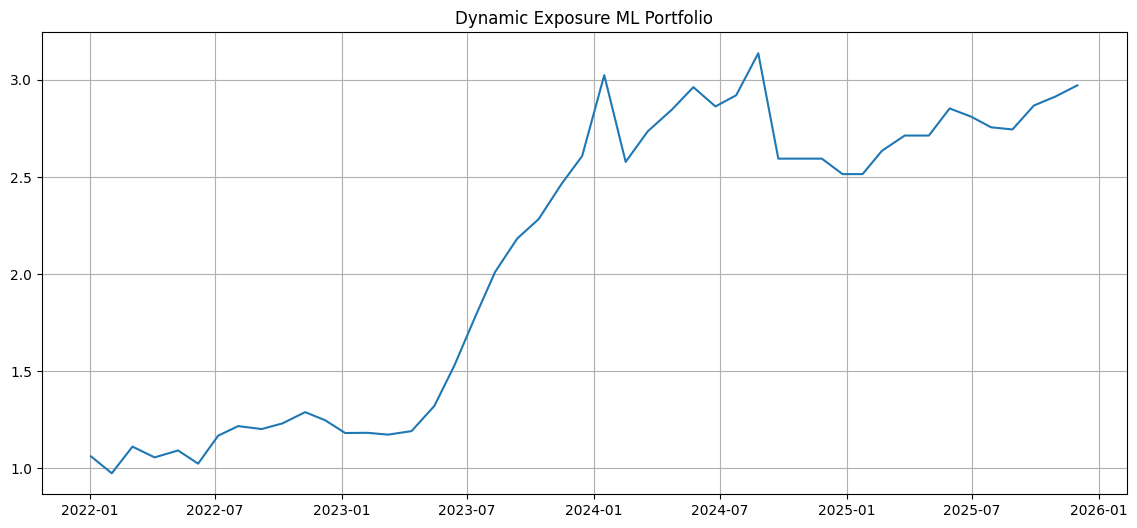

In [15]:
equity = (
    1 +
    portfolio_returns
).cumprod()

plt.figure(figsize=(14,6))

plt.plot(equity)

plt.title(
    "Dynamic Exposure ML Portfolio"
)

plt.grid(True)

plt.show()